**Note**: This is a basic implementation of CNN-based NST, which may require an amount of time for inference.

## **1. Import Libraries**
---

In [22]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import vgg19, VGG19_Weights

import cv2
from PIL import Image

import os
import time
import math
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# from tqdm.notebook import tqdm

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## **2. Prepare Data**
---

In [24]:
# Normalization used in pre-trained VGG19
mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

# Unnormalize tensor
def unnormalize(tensor):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    tensor.clamp_(0, 1)
    return tensor

In [25]:
def load_image(img_path, size=(256,256)):
    img_transforms = transforms.Compose([
        transforms.Resize(size),
        transforms.CenterCrop(size),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std)
    ])

    img        = Image.open(img_path).convert('RGB')
    img_tensor = img_transforms(img)
    img_tensor = img_tensor.unsqueeze(0).to(device, torch.float)
    
    return img_tensor

In [26]:
def plot_image(tensor, title=None, save=False, save_path=None):
    img = tensor.detach().clone().cpu().squeeze(0)
    img = unnormalize(img)
    img = transforms.ToPILImage()(img)

    if save:
        save_path = save_path if save_path is not None else '../results/transfered_img.png'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        img.save(save_path)

    plt.figure()
    plt.imshow(img)
    if title:
        plt.title(title, pad=10)
    plt.axis('off')
    plt.show()

## **3. Loss Function & Model**
---

In [27]:
class TransferLoss(nn.Module):
    def __init__(self, content_weight=1, style_weight=1e6):
        super().__init__()

        self.content_weight = content_weight
        self.style_weight   = style_weight

        self.content_layer = 'conv2_1'
        self.style_layers  = ['conv1_1', 'conv2_1', 'conv3_1', 'conv4_1', 'conv5_1']

        self.loss_fn = nn.MSELoss()

    def _gram_matrix(self, tensor): # Case: batch_size=1
        B, C, H, W = tensor.size()
        tensor     = tensor.view(B * C, H * W)
        G          = torch.mm(tensor, tensor.t())
        return G.div(B * C * H * W)

    def forward(self, content_features, style_features, target_features):
        self.content_loss = self.loss_fn(content_features[self.content_layer],
                                         target_features[self.content_layer])
        
        self.style_loss = sum(
            self.loss_fn(self._gram_matrix(style_features[layer]),
                         self._gram_matrix(target_features[layer]))
            for layer in self.style_layers
        )

        self.total_loss = self.content_weight * self.content_loss + self.style_weight * self.style_loss
        return self.total_loss

    def get_loss(self):
        return self.content_loss, self.style_loss, self.total_loss

In [28]:
class VGG19_FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = vgg19(weights=VGG19_Weights.DEFAULT).features.eval()
        self.model.to(device)
        for param in self.model.parameters():
            param.requires_grad_(False)

        # self.layers = {'0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1', '19': 'conv4_1', '21': 'conv4_2', '28': 'conv5_1'}
        self.layers = {'0': 'conv1_1', '5': 'conv2_1', '10': 'conv3_1', '19': 'conv4_1', '28': 'conv5_1'}
        
    def forward(self, x):
        features = {}
        for idx, layer in self.model._modules.items():
            x = layer(x.to(device))
            if idx in self.layers:
                features[self.layers[idx]] = x
        return features

## **4. Traning**
---

In [ ]:
def plot_graph(losses):   
    plt.figure(figsize=(12, 6))

    plt.plot(losses['content'], label='Content Loss', color='blue')
    plt.plot(losses['style'], label='Style Loss', color='green')
    plt.plot(losses['total'], label='Total Loss', color='red')

    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Loss during Style Transfer Training')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def NST_image(content_img_path, style_img_path, output_path, extractor, transfer_loss_fn, target_size='same', steps=500, lr=0.05):
    
    if target_size == 'same':
        target_shape = Image.open(content_img_path).size # W x H
        content_img  = load_image(content_img_path, size=(target_shape[1], target_shape[0])) # H x W
        style_img    = load_image(style_img_path  , size=(target_shape[1], target_shape[0]))
    elif isinstance(target_size, tuple): 
        content_img = load_image(content_img_path, size=target_size)
        style_img   = load_image(style_img_path, size=target_size)
    else:
        print('Wrong size!')
        return
    
    content_features = extractor(content_img)
    style_features   = extractor(style_img)
    
    target_img = content_img.clone().requires_grad_(True).to(device)
    # optimizer  = torch.optim.AdamW([target_img], lr=lr)
    optimizer  = torch.optim.LBFGS([target_img], lr=lr)
    
    # Start style transfer
    losses = {
        'content': [],
        'style'  : [],
        'total'  : []
    }
    with tqdm(total=steps, desc='Processing Image', unit='step') as pbar:
        
        def closure():
            optimizer.zero_grad()
            target_features = extractor(target_img)
            transfer_loss   = transfer_loss_fn(content_features, style_features, target_features)
            transfer_loss.backward()
            return transfer_loss
        
        for step in range(1, steps + 1):
            optimizer.step(closure)
            
            # Print log
            C, S, T = transfer_loss_fn.get_loss()

            losses['content'].append(C.item())
            losses['style'].append(S.item())
            losses['total'].append(T.item())

            # print(f"STEP [{step}/{steps}] \t| Content Loss: {C:.6f} \t| Style Loss {S:.6f} \t| Total loss: {T:.8f}")

            # Plot image
            if step == 1 or step % 20 == 0:
                plot_image(target_img, f"Target Image at step {step}")
            if step == steps:
                plot_image(target_img, f"Target Image", save=True, save_path=output_path)
                print('Target Image saved!')

            # Update pbar
            pbar.update(1)

    # Plot losses graph
    plot_graph(losses)

Processing Image:   0%|          | 0/500 [00:00<?, ?step/s]

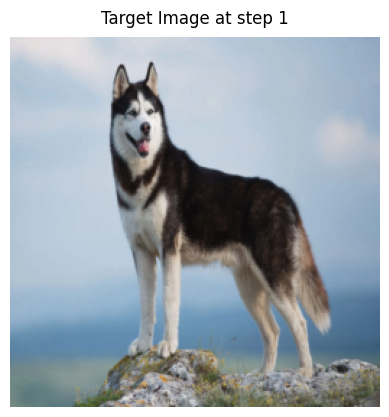

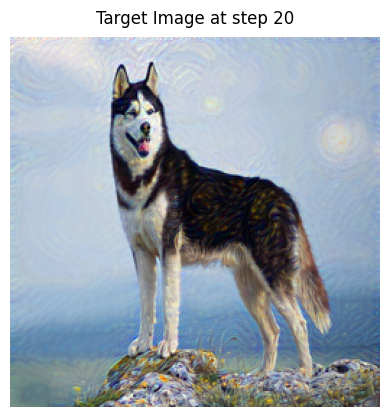

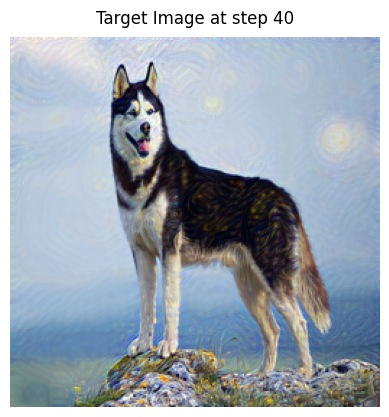

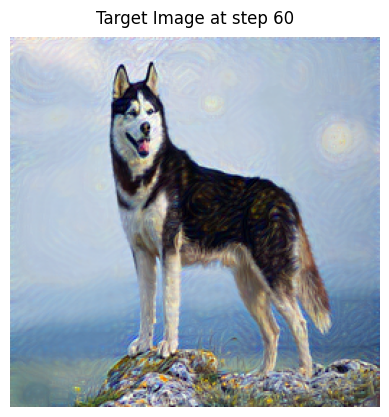

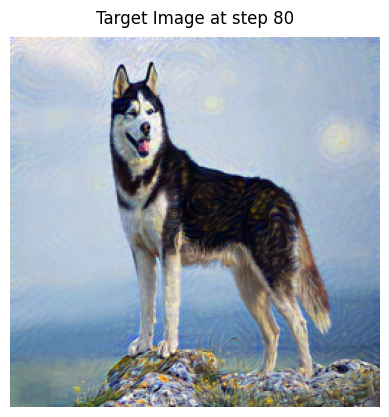

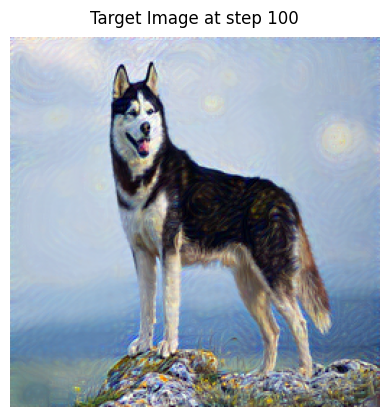

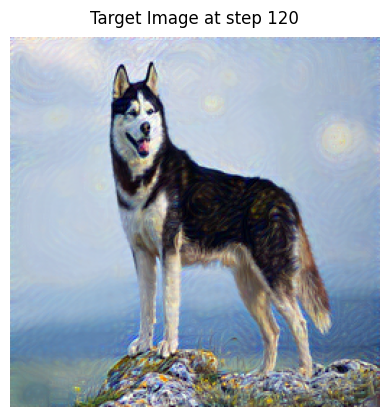

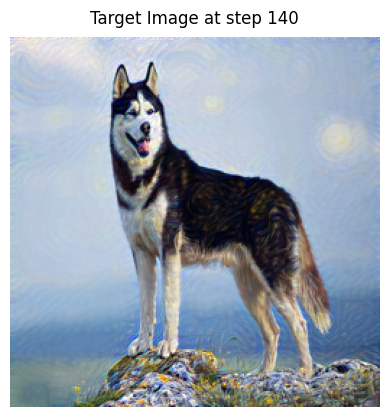

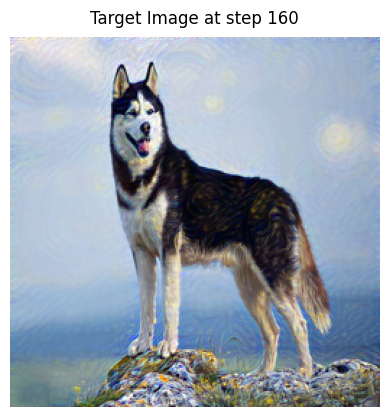

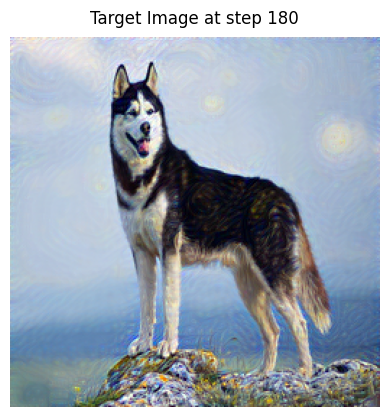

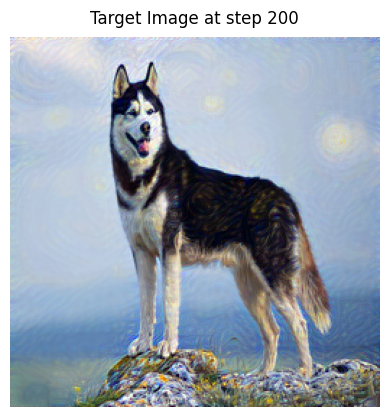

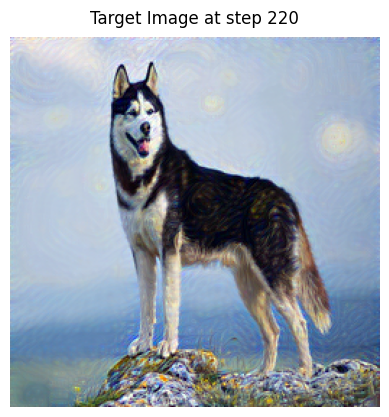

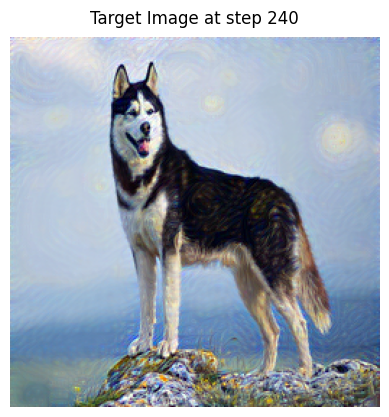

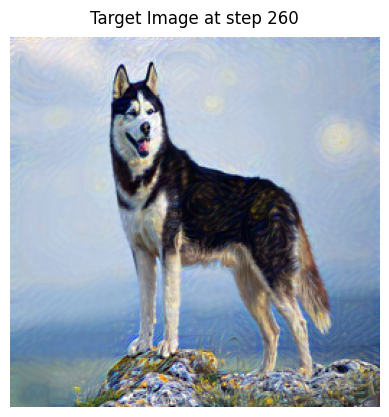

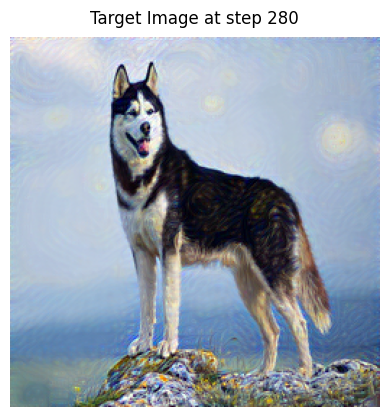

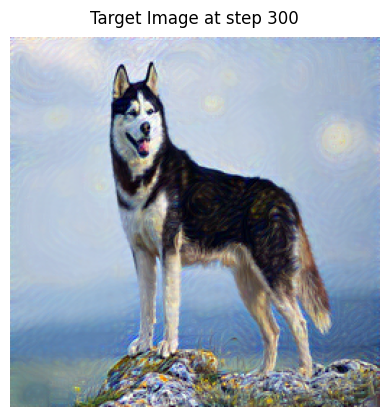

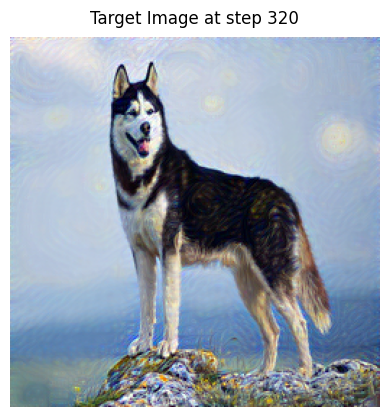

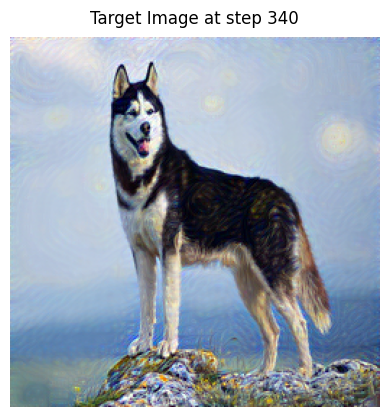

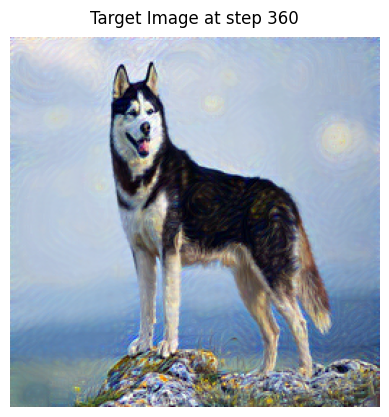

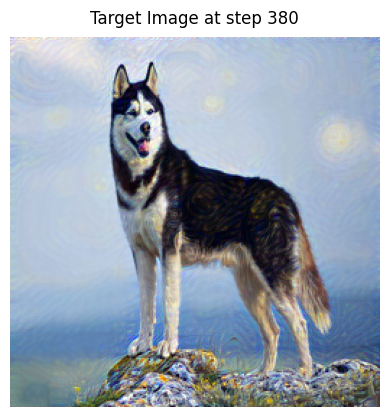

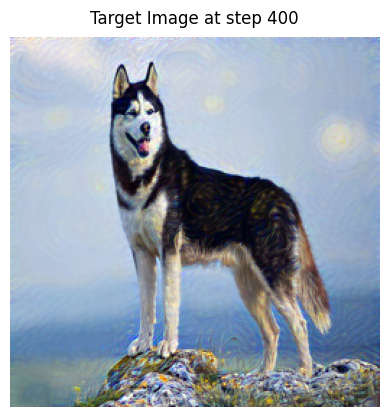

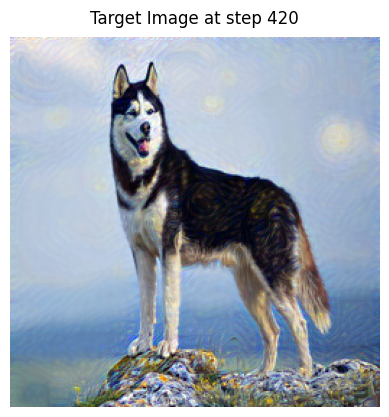

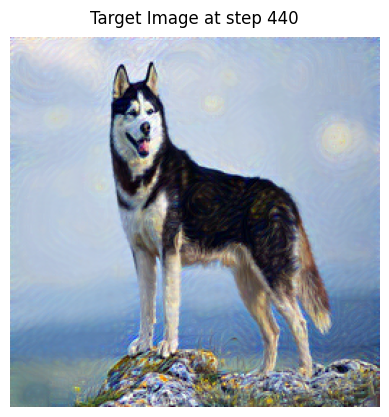

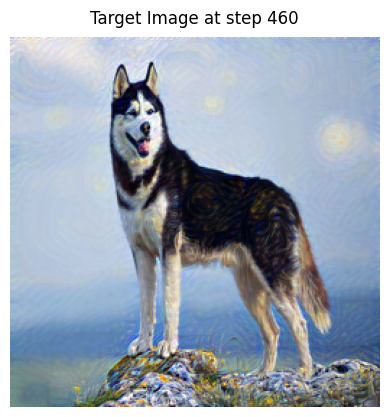

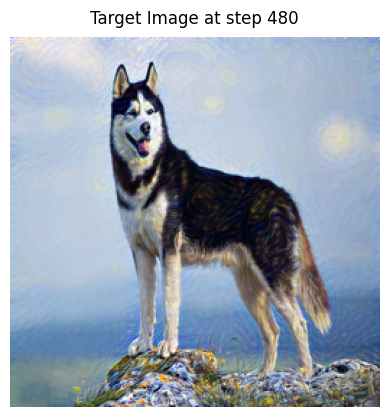

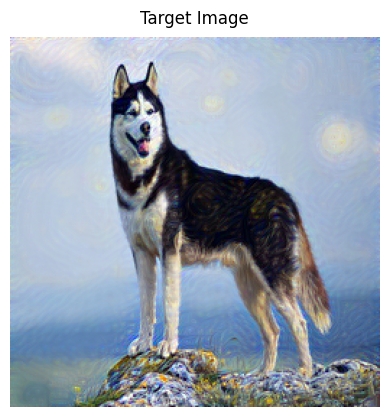

Target Image saved!


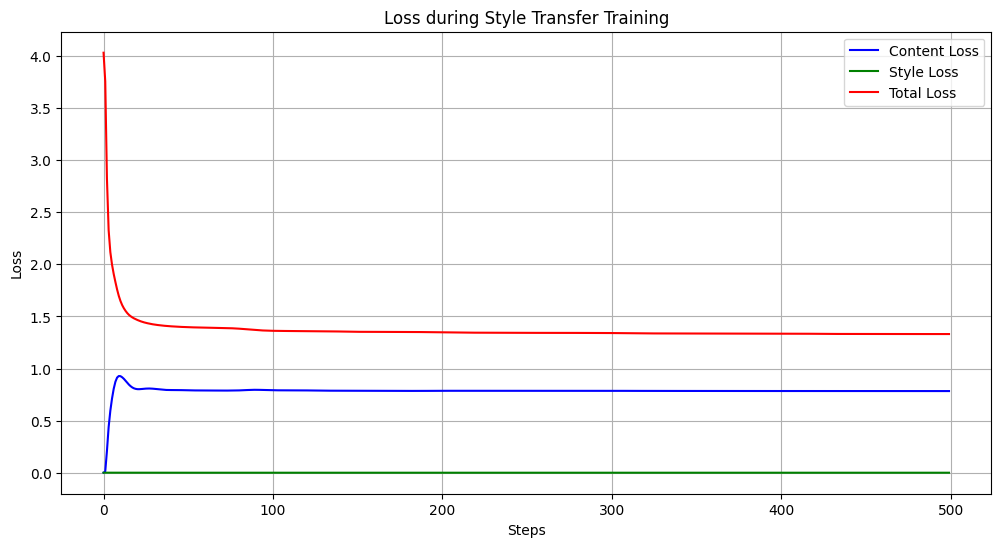

In [31]:
# Extractor and Loss Funcntion
extractor        = VGG19_FeatureExtractor()
transfer_loss_fn = TransferLoss(content_weight=1, style_weight=1e4)
transfer_loss_fn.to(device)

# NST
NST_image(
    content_img_path='/kaggle/input/tmp-dataset/images/content.png', 
    style_img_path='/kaggle/input/tmp-dataset/images/style1.png', 
    output_path='results/transfered_img.png', 
    extractor=extractor, 
    transfer_loss_fn=transfer_loss_fn, 
    target_size=(256,256),
    steps=500, 
    lr=0.02
)